# **02. SQL Analysis of clean dataset**

This notebook presents a structured analysis of the retail sales dataset using SQL queries. The analysis is organized into four sections:
1. **Revenue analysis**: examines revenue trends over time to identify seasonal patterns, and ranks products and countries by their contribution to total revenue.   

2. **Volume analysis**: mirrors the revenue analysis from a volume perspective. Since product prices vary significantly, volume and revenue rankings may diverge; this section helps clarify those differences.

3. **Returns analysis**: investigates return rates over time, identifying which countries and products account for the highest proportion of returns.

4. **Customer analysis**: investigates return rates over time, identifying which countries and products account for the highest proportion of returns.    

In [1]:
import sys
sys.path.append('../src')
from models import SalesRecord, ReturnRecord, Invoice

import pandas as pd
import sqlite3
from sqlalchemy import create_engine

In [2]:
import matplotlib.pyplot as plt

In [3]:
df_sales = pd.read_csv("../data/sales_clean.csv")
df_returns = pd.read_csv("../data/returns_clean.csv")

In [4]:
# create SQLite database
engine = create_engine("sqlite:///../data/retail.db")

# load dataframes
df_sales.to_sql('sales', engine, if_exists='replace', index=False)
df_returns.to_sql('returns', engine, if_exists='replace', index=False)

17946

## 2.1 Revenue analysis

For the following revenue analysis, net revenue is considered after subtracting the revenue loss due to returns to the revenue gain from sales. While a separate section focuses on the returns analysis, it has been deemed meaningful to analyze net revenue since it is arguably the most important indicator for a company.    
The temporal analysis shows the net revenue agains the sales revenue, to better understand the gap between the two, while successive revenue trends only focus on the net revenue.

### 2.1.1 Temporal revenue trends

#### **Monthly revenue trend**
To get a general overview of revenue trends, let us first visualize them across all months.

In [45]:
q_net_revenue = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    GROUP BY year_month
    ORDER BY year_month
    """

q_sales = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """

df_net_rev = pd.read_sql(q_net_revenue,engine) # Net revenue
df_sal_rev = pd.read_sql(q_sales,engine)   # Sales revenue

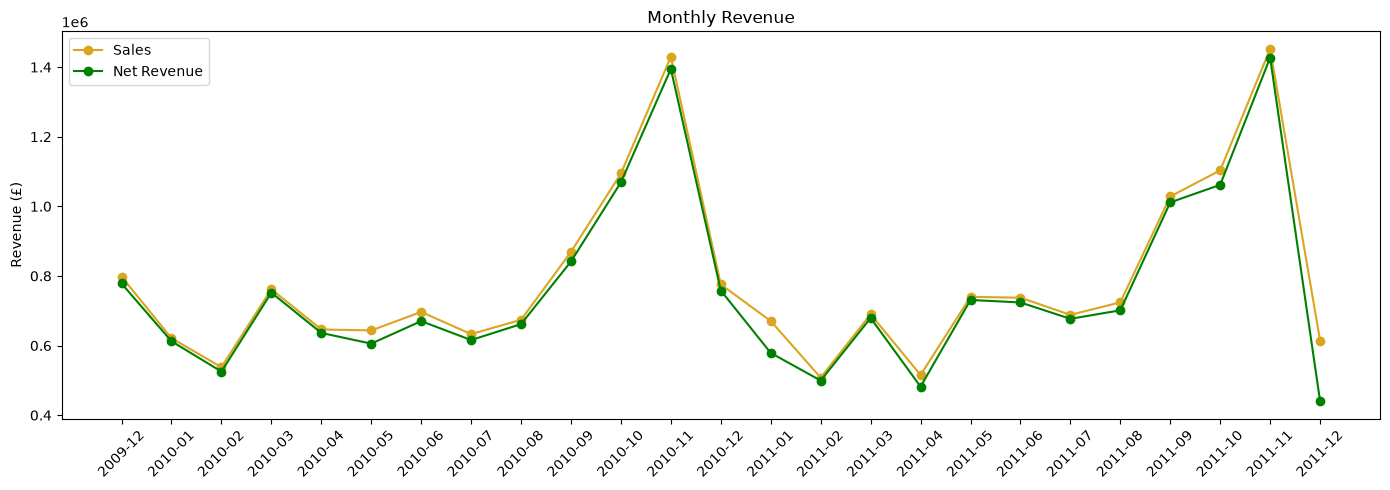

In [46]:
# Plot results
plt.figure(figsize=(14,5))
#plt.plot(df_ret["year_month"], df_ret["revenue"],c="red", label="Returns")
plt.plot(df_sal_rev["year_month"], df_sal_rev["revenue"],c="goldenrod", label="Sales", marker='o')
plt.plot(df_net_rev["year_month"], df_net_rev["revenue"],c="green", label="Net Revenue", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.ylabel("Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

#### **Quarterly revenue trend**
For this step of the analysis, the 2009 year has been left out, since the dataset only contains data for the month of December 2009.    

In [17]:
q_net_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    WHERE year!='2009'
    GROUP BY year, quarter
    """

q_sal_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

df_net_rev_quart = pd.read_sql(q_net_rev_quart,engine)
df_sal_rev_quart = pd.read_sql(q_sal_rev_quart,engine)

df_net_rev_quart["year_quarter"] = df_net_rev_quart["year"] + "-" + df_net_rev_quart["quarter"]
df_sal_rev_quart["year_quarter"] = df_sal_rev_quart["year"] + "-" + df_sal_rev_quart["quarter"]

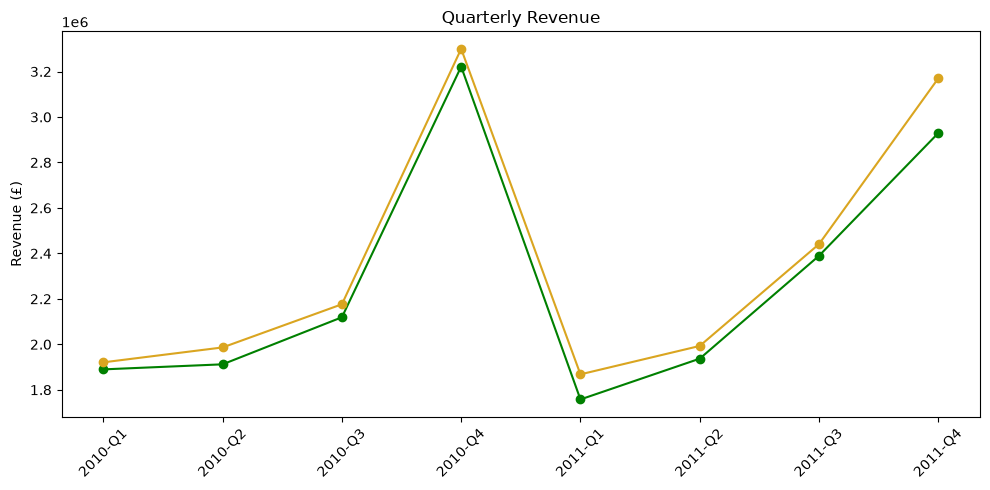

In [18]:
plt.figure(figsize=(10,5))
plt.plot(df_net_rev_quart["year_quarter"], df_net_rev_quart["revenue"],c="green", marker='o', label="Net Revenue")
plt.plot(df_sal_rev_quart["year_quarter"], df_sal_rev_quart["revenue"],c="goldenrod", marker='o', label="Sales Revenue")
plt.xticks(rotation=45)
plt.title("Quarterly Revenue")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

The trend seems to be consistent for the 4 quarters of years 2010-2011: The total revenue slowly increases from Q1 to Q3, which is followed by a steep increase in revenue in Q4.    
The total revenue then drops again by Q1.    
This behaviour may be consistent with the generally high volume of sales that most stores experience when festivities approach, which mostly occur in Q4.

### 2.1.2 Revenue per Country

In [19]:
q_country_net_rev = """
    SELECT SUM(Price*Quantity) AS revenue, Country
    FROM (SELECT Country, Price, Quantity FROM sales
        UNION ALL
        SELECT Country, Price, Quantity FROM returns
        )
    GROUP BY Country
    ORDER BY revenue DESC
    """

df_country_net_rev = pd.read_sql(q_country_net_rev, engine)

Text(0, 0.5, 'Revenue (£)')

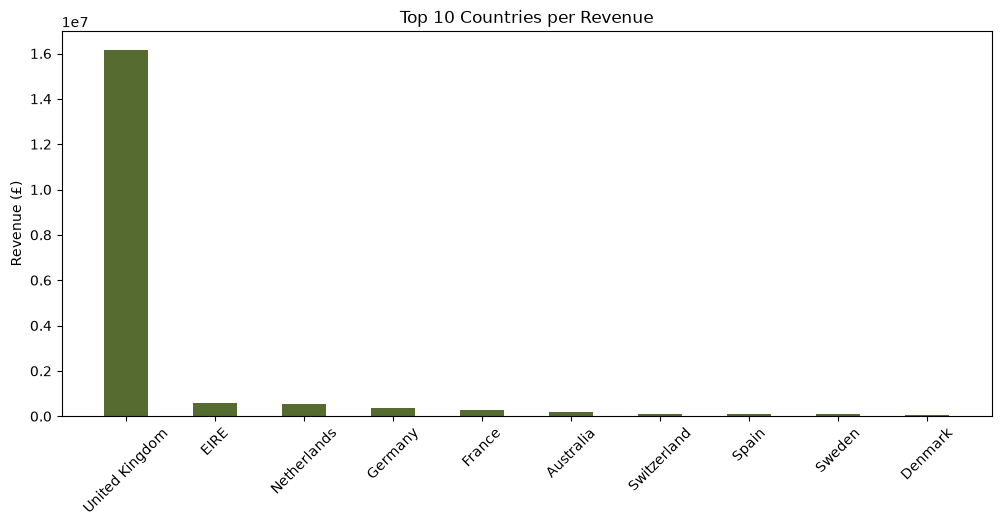

In [23]:
plt.figure(figsize=(12,5))
plt.bar(df_country_net_rev["Country"][:10], df_country_net_rev["revenue"][:10], width=0.5, color="darkolivegreen")
plt.xticks(rotation=45)
plt.title("Top 10 Countries per Revenue")
plt.ylabel("Revenue (£)")


### 2.1.3 Revenue per Product

In [24]:
q_prod_net_rev = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(Price*Quantity) as revenue
    FROM (SELECT StockCode, Description, Price, Quantity FROM sales
        UNION ALL
        SELECT StockCode, Description, Price, Quantity FROM returns
        )
    GROUP BY stock_code
    ORDER BY revenue DESC
    """

df_prod_net_rev = pd.read_sql(q_prod_net_rev, engine)

Text(0, 0.5, 'Revenue (£)')

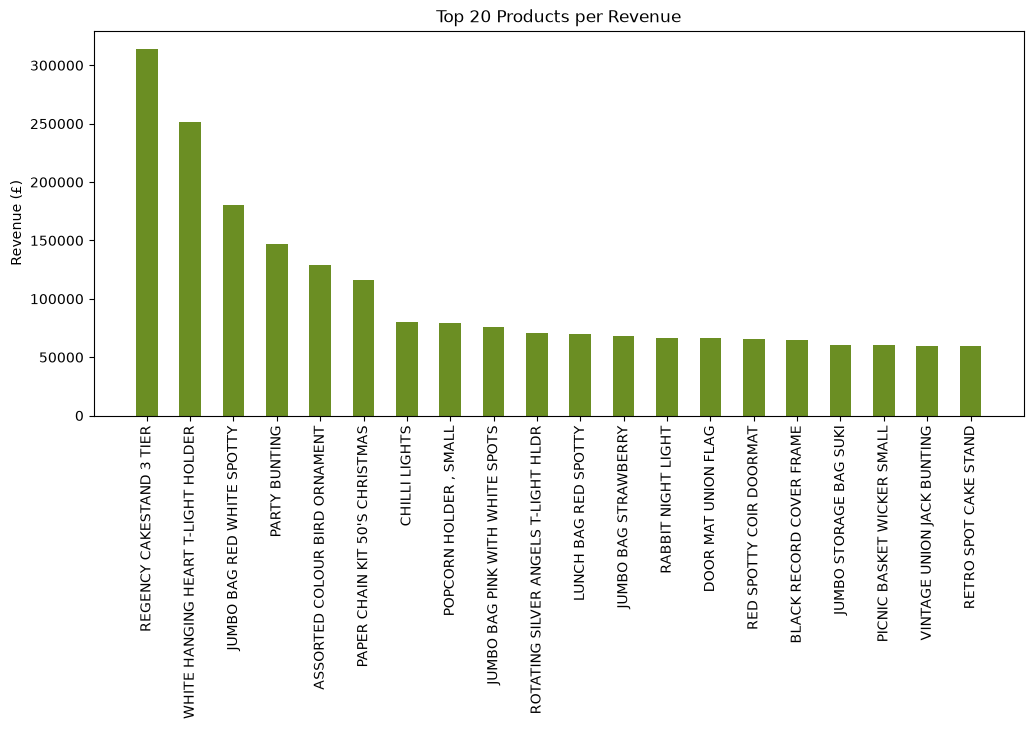

In [25]:
plt.figure(figsize=(12,5))
plt.bar(df_prod_net_rev["Description"][:20], df_prod_net_rev["revenue"][:20], width=0.5, color="olivedrab")
plt.xticks(rotation=90)
plt.title("Top 20 Products per Revenue")
plt.ylabel("Revenue (£)")


## 2.2 Volume analysis
The second step of the analysis focuses on the volume of sales, where we basically repeat the same analysis as we did for revenue, this time focusing on the number of sales.    
Since the returns analysis will be performed separately, this section only focuses on the total number of sales without taking returns into consideration.

### 2.2.1 Temporal volume trends

#### **Monthly volume of sales**

In [36]:
q_sal_vol = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, COUNT(*) AS volume
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """
df_sal_vol = pd.read_sql(q_sal_vol,engine)   # Sales revenue

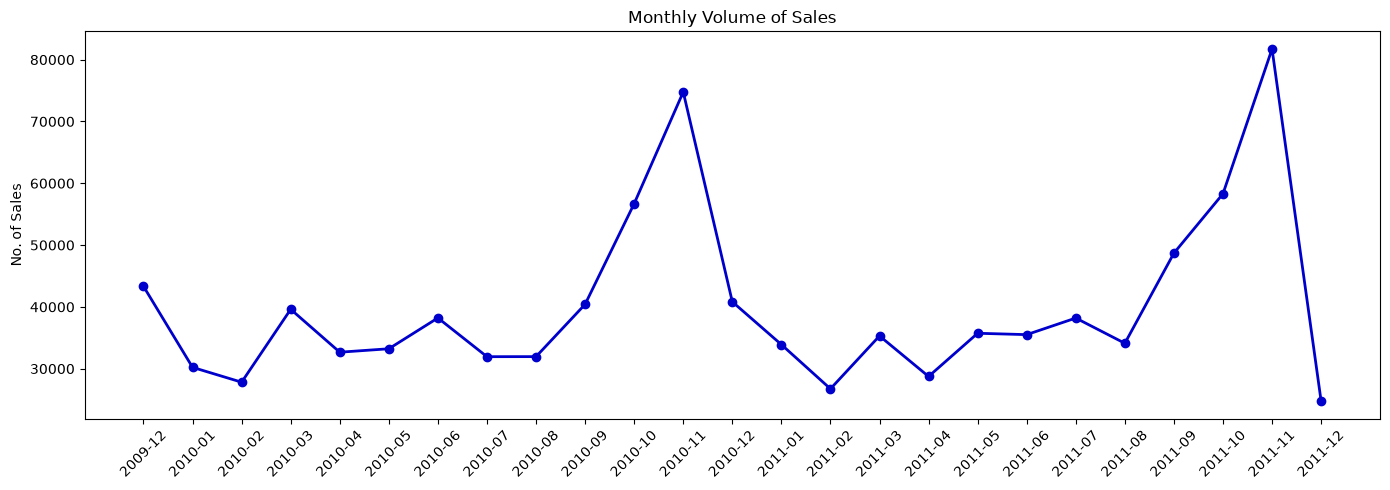

In [47]:

# Plot results
plt.figure(figsize=(14,5))
plt.plot(df_sal_vol["year_month"], df_sal_vol["volume"],c="mediumblue",linewidth=2, label="Sales", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Volume of Sales")
plt.ylabel("No. of Sales")
plt.tight_layout()
plt.show()

#### **Quarterly volume of sales**

In [27]:
q_vol_quart = """
    SELECT COUNT(*) AS volume, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

df_sal_quart = pd.read_sql(q_vol_quart,engine)
df_sal_quart["year_quarter"] = df_sal_quart["year"] + "-" + df_sal_quart["quarter"]

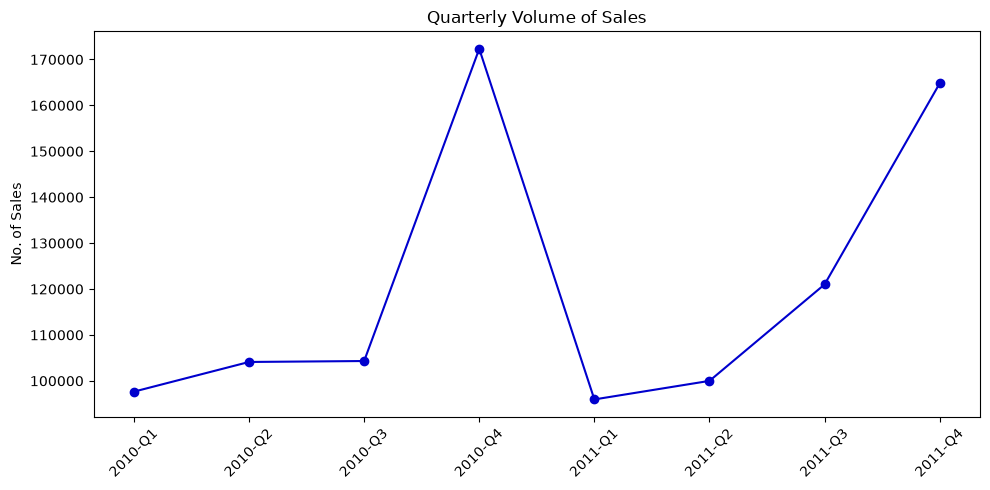

In [34]:
plt.figure(figsize=(10,5))
plt.plot(df_sal_quart["year_quarter"], df_sal_quart["volume"],c="mediumblue", marker='o')
plt.xticks(rotation=45)
plt.title("Quarterly Volume of Sales")
plt.ylabel("No. of Sales")
plt.tight_layout()
plt.show()

Predictably, the quarterly trend for the volume of sales closely follows the one observed for the sales revenue.

### 2.2.2 Volume of sales per Country

In [29]:
q_country_vol = """
    SELECT COUNT(*) as volume, Country
    FROM sales
    GROUP BY Country
    ORDER BY volume DESC
    """

df_country_vol = pd.read_sql(q_country_vol, engine)

Text(0, 0.5, 'No. of Sales')

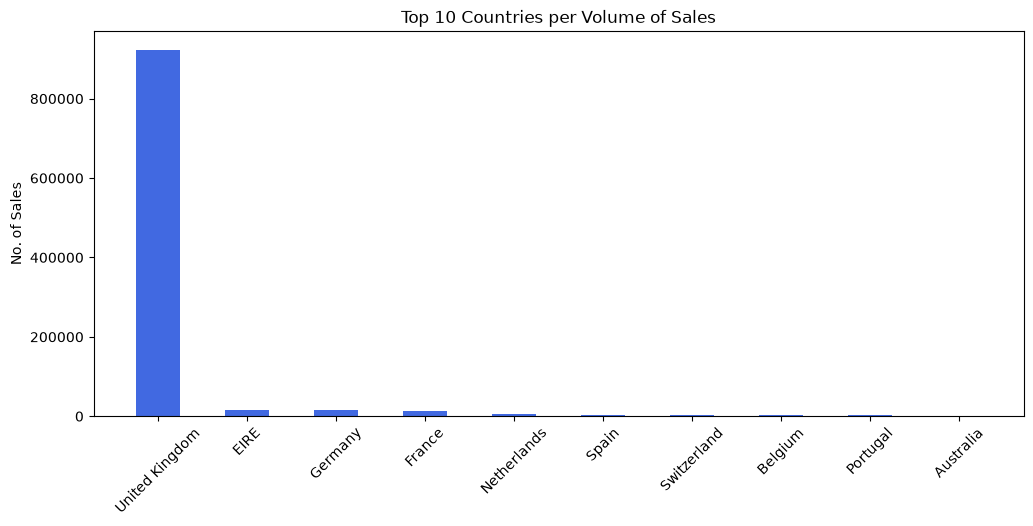

In [31]:
plt.figure(figsize=(12,5))
plt.bar(df_country_vol["Country"][:10], df_country_vol["volume"][:10], width=0.5, color="royalblue")
plt.xticks(rotation=45)
plt.title("Top 10 Countries per Volume of Sales")
plt.ylabel("No. of Sales")


### 2.2.3 Volume of sales per Product

In [32]:
q_prod_vol = """
    SELECT UPPER(StockCode) as stock_code, Description, COUNT(*) as volume
    FROM sales
    GROUP BY stock_code
    ORDER BY volume DESC
    """

df_prod_vol = pd.read_sql(q_prod_vol, engine)

Text(0, 0.5, 'No. of Sales')

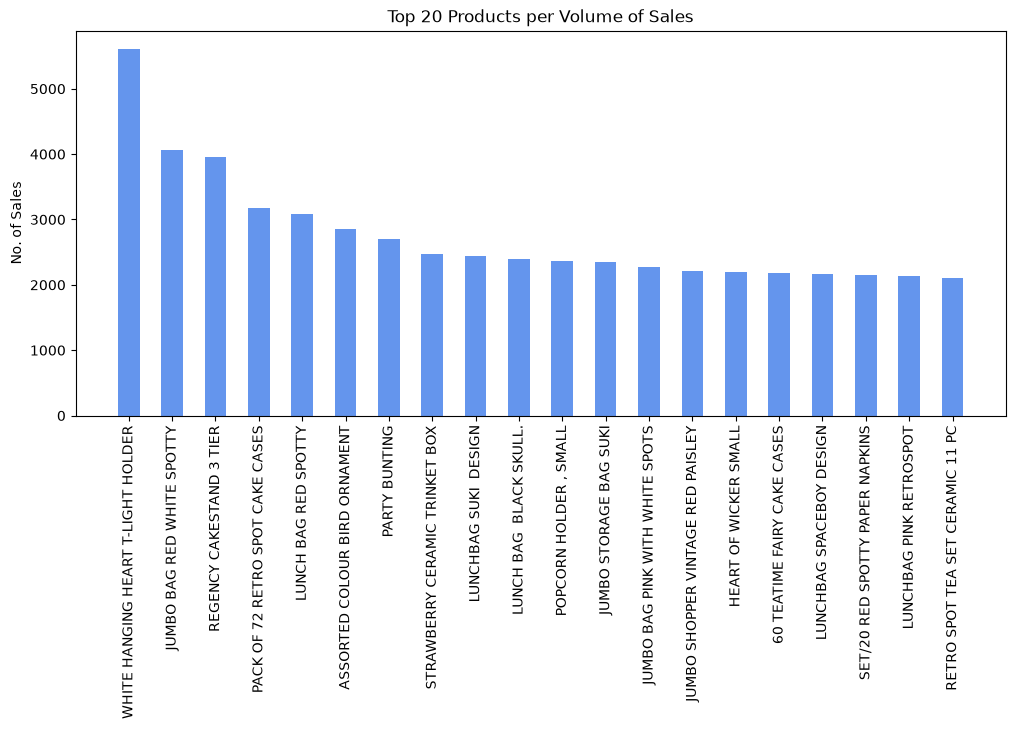

In [33]:
plt.figure(figsize=(12,5))
plt.bar(df_prod_vol["Description"][:20], df_prod_vol["volume"][:20], width=0.5, color="cornflowerblue")
plt.xticks(rotation=90)
plt.title("Top 20 Products per Volume of Sales")
plt.ylabel("No. of Sales")


## 2.3 Returns analysis

### 2.3.1 Temporal return rate trends

For the temporal analysis of returns we focus on the returns rate rather than the absolute number of returns, i.e. the percentage or returns over the total sales. To understand this choice, in the monthly returns analysis I will visualize both.

#### **Monthly returns**

In [38]:
# return rate
q_ret_vol = """
    SELECT COUNT(*) as volume, strftime('%Y-%m', InvoiceDate) as year_month FROM returns
    GROUP BY year_month
    ORDER BY year_month
    """

df_ret_vol = pd.read_sql(q_ret_vol,engine)

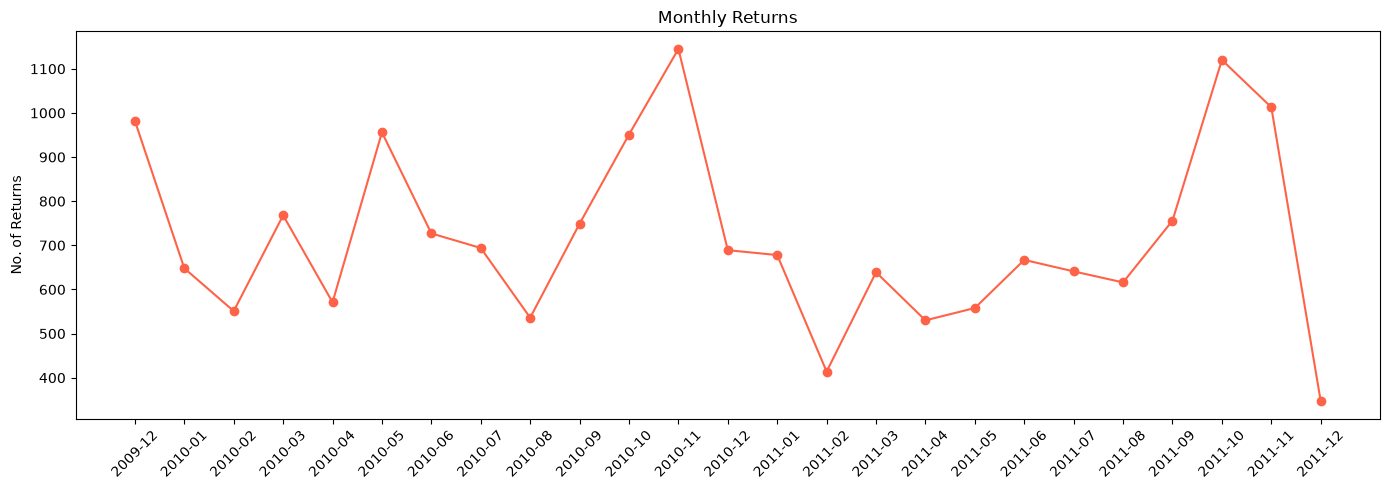

In [51]:
plt.figure(figsize=(14,5))
plt.plot(df_ret_vol["year_month"], df_ret_vol["volume"],c="tomato", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Returns")
plt.ylabel("No. of Returns")
plt.tight_layout()
plt.show()

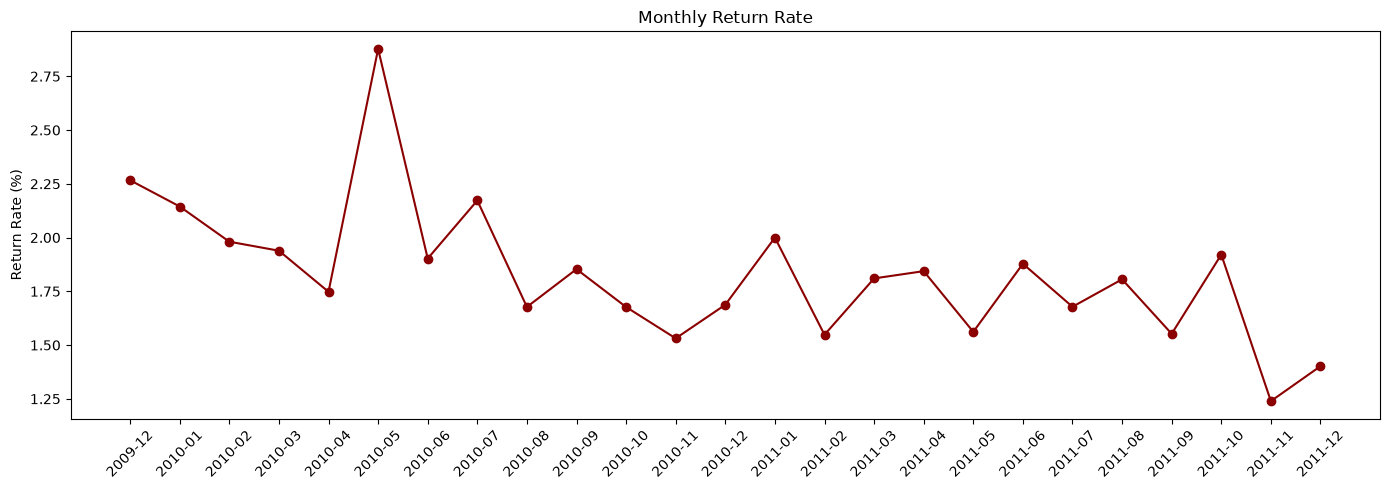

In [48]:
plt.figure(figsize=(14,5))
plt.plot(df_ret_vol["year_month"], df_ret_vol["volume"]/df_sal_vol["volume"]*100,c="darkred", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Return Rate")
plt.ylabel("Return Rate (%)")
plt.tight_layout()
plt.show()

By comparing the trends for the number of returns and the return rate one can understand the choice behind monitoring the return rate. The return rate is more informative, as it relates the returns with the total number of sales: a higher number of returns could indicate a problem with a product or with the company in a certain period, or it could just be naturally caused by the higher amount of sales.    
A peak in number of returns could be only caused by the higher volume of sales, and looking at it in absolute terms could alert the company of potential issues that are not there.    

To gather insight on the actual trend in returns, and what they are caused by, it's important to always relate them with the total number of sales.

#### **Quarterly Return Rate**

In [41]:
q_ret_vol_quart = """
    SELECT COUNT(*) AS volume, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM returns
    WHERE year!='2009'
    GROUP BY year, quarter
    """
df_ret_quart = pd.read_sql(q_ret_vol_quart,engine)
df_ret_quart["year_quarter"] = df_ret_quart["year"] + "-" + df_ret_quart["quarter"]

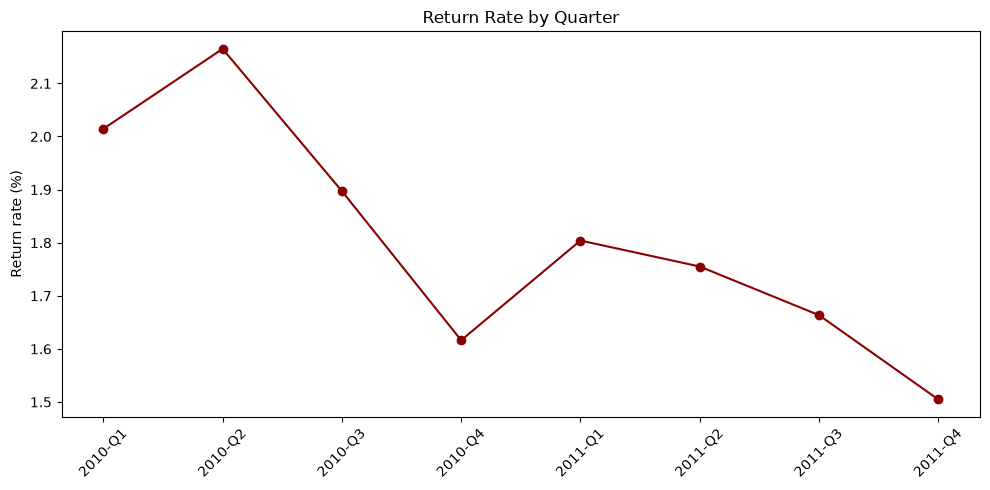

In [52]:
plt.figure(figsize=(10,5))
plt.plot(df_ret_quart["year_quarter"], df_ret_quart["volume"]/df_sal_quart["volume"]*100,c="darkred", marker='o')
plt.xticks(rotation=45)
plt.title("Return Rate by Quarter")
plt.ylabel("Return rate (%)")
plt.tight_layout()
plt.show()

### 2.3.2 Return rate per Country

In [57]:
q_country_ret = """
    SELECT 
    s.Country,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
FROM (
    SELECT Country, COUNT(*) AS sales_volume 
    FROM sales 
    GROUP BY Country
) s
LEFT JOIN (
    SELECT Country, COUNT(*) AS return_volume 
    FROM returns 
    GROUP BY Country
) r ON s.Country = r.Country
ORDER BY return_rate DESC
    """

df_country_ret = pd.read_sql(q_country_ret, engine)


Text(0, 0.5, 'Return Rate (%)')

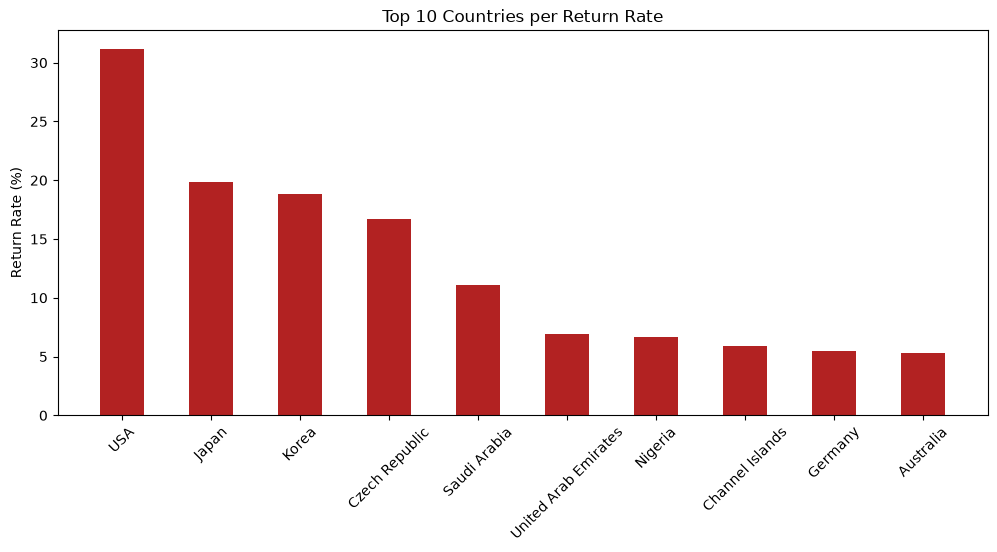

In [59]:
plt.figure(figsize=(12,5))
plt.bar(df_country_ret["Country"][:10], df_country_ret["return_rate"][:10], width=0.5, color="firebrick")
plt.xticks(rotation=45)
plt.title("Top 10 Countries per Return Rate")
plt.ylabel("Return Rate (%)")


### 2.3.3 Return rate per Product